In [28]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os

sys.path.append(
    os.path.abspath("..")
)


from scipy.stats import norm
from scipy.optimize import minimize
from scipy.stats import ks_2samp
from scipy.stats import wasserstein_distance

from diffusionApp import DiffusionApp

In [29]:
app = DiffusionApp(
    n_samples=50000,
    T=500
)

# generar distribución compleja
app.generar_datos(
    min_picos=2,
    max_picos=10,
    complejidad=0,
    target_mean=-30
)

# crear forward diffusion
app.crear_diffusion()

# simular forward
app.diff.simular()

# entrenar red neuronal
app.entrenar_modelo(
    epochs=3000
)

# generar muestras reconstruidas
app.generar_muestras(
    n_samples=5000
)

✔ Datos generados
✔ Forward diffusion creado
Epoch 0 | Loss: 0.9682
Epoch 200 | Loss: 0.3848
Epoch 400 | Loss: 0.4092
Epoch 600 | Loss: 0.3283
Epoch 800 | Loss: 0.3454
Epoch 1000 | Loss: 0.3633
Epoch 1200 | Loss: 0.3387
Epoch 1400 | Loss: 0.3393
Epoch 1600 | Loss: 0.4245
Epoch 1800 | Loss: 0.3105
Epoch 2000 | Loss: 0.3624
Epoch 2200 | Loss: 0.3953
Epoch 2400 | Loss: 0.3745
Epoch 2600 | Loss: 0.3398
Epoch 2800 | Loss: 0.3659
✔ Modelo entrenado
✔ Muestras generadas


In [30]:
original = app.data * app.std + app.mean
reconstruido = app.trayectoria[-1] * app.std + app.mean

print("Original shape:", original.shape)
print("Reconstruido shape:", reconstruido.shape)

Original shape: (49996,)
Reconstruido shape: (5000,)


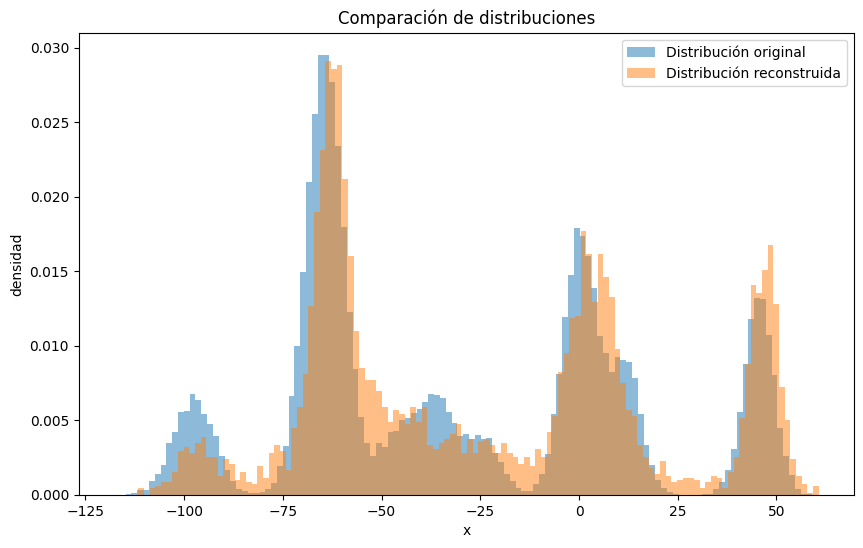

In [31]:
plt.figure(figsize=(10,6))

plt.hist(
    original,
    bins=120,
    density=True,
    alpha=0.5,
    label="Distribución original"
)

plt.hist(
    reconstruido,
    bins=120,
    density=True,
    alpha=0.5,
    label="Distribución reconstruida"
)

plt.legend()
plt.title("Comparación de distribuciones")
plt.xlabel("x")
plt.ylabel("densidad")

plt.show()

In [32]:
def negative_log_likelihood(params, data):

    mu, sigma = params

    if sigma <= 0:
        return np.inf

    likelihoods = norm.pdf(data, mu, sigma)

    # evitar log(0)
    likelihoods = np.clip(
        likelihoods,
        1e-12,
        None
    )

    return -np.sum(np.log(likelihoods))

In [33]:
initial_guess = [
    np.mean(original),
    np.std(original)
]

result_original = minimize(
    negative_log_likelihood,
    initial_guess,
    args=(original,)
)

mu_original, sigma_original = result_original.x

In [34]:
result_reconstruido = minimize(
    negative_log_likelihood,
    initial_guess,
    args=(reconstruido,)
)

mu_reconstruido, sigma_reconstruido = result_reconstruido.x

In [35]:
print("\n==============================")
print("MÁXIMA VEROSIMILITUD")
print("==============================\n")

print("ORIGINAL")
print(f"mu     = {mu_original:.4f}")
print(f"sigma  = {sigma_original:.4f}")

print("\nRECONSTRUIDO")
print(f"mu     = {mu_reconstruido:.4f}")
print(f"sigma  = {sigma_reconstruido:.4f}")


MÁXIMA VEROSIMILITUD

ORIGINAL
mu     = -30.0000
sigma  = 43.4649

RECONSTRUIDO
mu     = -23.7537
sigma  = 43.4097


In [36]:
error_mu = abs(
    mu_original - mu_reconstruido
)

error_sigma = abs(
    sigma_original - sigma_reconstruido
)

print("\n==============================")
print("ERRORES")
print("==============================\n")

print(f"Error mu: {error_mu:.4f}")
print(f"Error sigma: {error_sigma:.4f}")


ERRORES

Error mu: 6.2463
Error sigma: 0.0552


In [37]:
wasserstein = wasserstein_distance(
    original,
    reconstruido
)

print("\n==============================")
print("DISTANCIA WASSERSTEIN")
print("==============================\n")

print(f"Wasserstein = {wasserstein:.4f}")


DISTANCIA WASSERSTEIN

Wasserstein = 6.2463


In [38]:
ks_stat, p_value = ks_2samp(
    original,
    reconstruido
)

print("\n==============================")
print("KOLMOGOROV-SMIRNOV")
print("==============================\n")

print(f"KS statistic = {ks_stat:.6f}")
print(f"p-value      = {p_value:.6f}")

if p_value > 0.05:
    print("\nNo se rechaza H0:")
    print("las distribuciones podrían ser iguales")
else:
    print("\nSe rechaza H0:")
    print("las distribuciones son diferentes")


KOLMOGOROV-SMIRNOV

KS statistic = 0.094303
p-value      = 0.000000

Se rechaza H0:
las distribuciones son diferentes


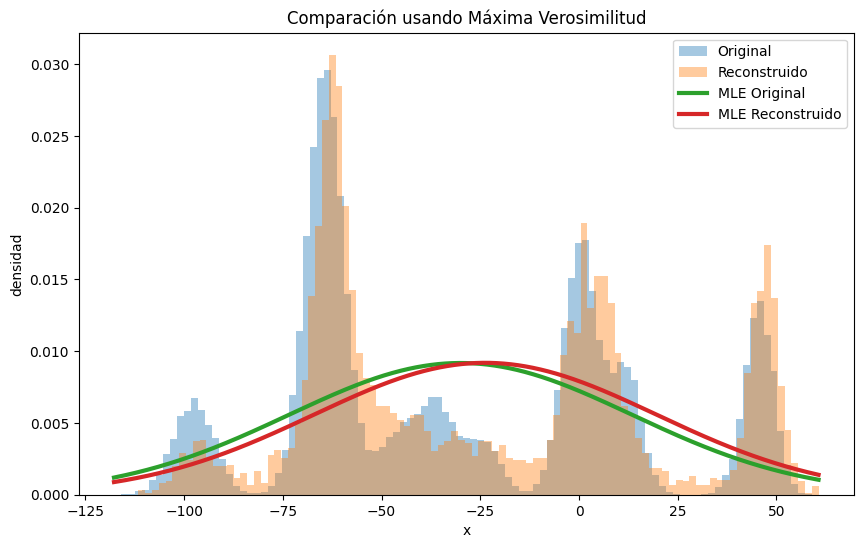

In [39]:
x = np.linspace(
    min(min(original), min(reconstruido)),
    max(max(original), max(reconstruido)),
    2000
)

pdf_original = norm.pdf(
    x,
    mu_original,
    sigma_original
)

pdf_reconstruido = norm.pdf(
    x,
    mu_reconstruido,
    sigma_reconstruido
)

plt.figure(figsize=(10,6))

plt.hist(
    original,
    bins=100,
    density=True,
    alpha=0.4,
    label="Original"
)

plt.hist(
    reconstruido,
    bins=100,
    density=True,
    alpha=0.4,
    label="Reconstruido"
)

plt.plot(
    x,
    pdf_original,
    linewidth=3,
    label="MLE Original"
)

plt.plot(
    x,
    pdf_reconstruido,
    linewidth=3,
    label="MLE Reconstruido"
)

plt.legend()

plt.title(
    "Comparación usando Máxima Verosimilitud"
)

plt.xlabel("x")
plt.ylabel("densidad")

plt.show()

In [40]:
stats = app.evaluar()

print(stats)


    === EVALUACIÓN REAL ===

    Media:      -30.00 vs -23.75
    Varianza:   1889.20 vs 1884.40
    Skewness:   0.31 vs 0.27
    Kurtosis:   -1.03 vs -1.14

    Distancia Wasserstein: 6.2463

    Calidad del modelo: MALA ❌
    
{'media_original': np.float64(-30.000000000000018), 'media_generada': np.float64(-23.753695205301053), 'var_original': np.float64(1889.1978356420966), 'var_generada': np.float64(1884.4046253219128), 'skew_original': np.float64(0.3052977158346391), 'skew_generada': np.float64(0.2696293829588668), 'kurt_original': np.float64(-1.0295151933041906), 'kurt_generada': np.float64(-1.1357431268323215), 'wasserstein': np.float64(6.246304794698965)}
